In [1]:
import pandas as pd

# 构建数据
data = {
    'Concentration_uM': [0, 5, 10, 15, 20],
    'TP53_Expression_FPKM': [12.5, 11.0, 9.8, 8.2, 7.0]
}

# 创建 DataFrame
df = pd.DataFrame(data)

# 显示结果
print(df)


   Concentration_uM  TP53_Expression_FPKM
0                 0                  12.5
1                 5                  11.0
2                10                   9.8
3                15                   8.2
4                20                   7.0


In [2]:
# 药物浓度（X）与 TP53 表达量（Y）
X = [0, 5, 10, 15, 20]
Y = [12.5, 11.0, 9.8, 8.2, 7.0]

# 计算均值
def mean(values):
    total = 0
    for v in values:
        total += v
    return total / len(values)

mean_x = mean(X)
mean_y = mean(Y)

# 计算协方差
def covariance(X, Y, mean_x, mean_y):
    cov = 0
    for i in range(len(X)):
        cov += (X[i] - mean_x) * (Y[i] - mean_y)
    return cov

# 计算方差
def variance(values, mean_val):
    var = 0
    for v in values:
        var += (v - mean_val) ** 2
    return var

cov_xy = covariance(X, Y, mean_x, mean_y)
var_x = variance(X, mean_x)

# 回归系数
a = cov_xy / var_x
b = mean_y - a * mean_x

print(f"回归方程：Y = {a:.2f} * X + {b:.2f}")

# 预测浓度为 25μM 时的表达量
x_new = 25
y_pred = a * x_new + b
print(f"预测浓度为 25μM 时表达量为：{y_pred:.2f}")


回归方程：Y = -0.28 * X + 12.46
预测浓度为 25μM 时表达量为：5.56


In [3]:
X = [0, 5, 10, 15, 20]
Y = [12.5, 11.0, 9.8, 8.2, 7.0]


# 计算 X 的均值
total_x = 0
for x in X:
    total_x += x
mean_x = total_x / len(X)

# 计算 Y 的均值
total_y = 0
for y in Y:
    total_y += y
mean_y = total_y / len(Y)

print("mean_x =", mean_x)
print("mean_y =", mean_y)


# 协方差 = 所有样本的 [(X值 - X均值) × (Y值 - Y均值)] 的总和 ÷ 样本数量
cov_xy = 0
for i in range(len(X)):
    cov_xy += (X[i] - mean_x) * (Y[i] - mean_y)

print("协方差 cov_xy =", cov_xy)

var_x = 0
for x in X:
    var_x += (x - mean_x) ** 2

print("方差 var_x =", var_x)

a = cov_xy / var_x
b = mean_y - a * mean_x

print("回归方程：Y = {:.2f} * X + {:.2f}".format(a, b))

x_new = 25
y_pred = a * x_new + b

print("预测浓度为 25μM 时表达量为：{:.2f}".format(y_pred))


mean_x = 10.0
mean_y = 9.7
协方差 cov_xy = -69.0
方差 var_x = 250.0
回归方程：Y = -0.28 * X + 12.46
预测浓度为 25μM 时表达量为：5.56


In [6]:
X = [5.2,6.1,7.0,8.3,9.1]
Y = [0.42,0.50,0.58,0.65,0.72]

'''
🎯 任务目标
用线性回归拟合表达量与存活率的关系

写出回归方程：存活率 = a × 表达量 + b

解释斜率 a 的生物意义

预测当表达量为 10.0 时，细胞存活率是多少？
'''
for i in X:
    mean_X = sum(X)/len(X)
    diff_X_square = [(i - mean_X)**2 for i in X]
    var_X = sum(diff_X_square)
for i in Y:
    mean_Y = sum(Y)/len(Y)
    diff_Y_square = [(i - mean_Y)**2 for i in Y]
    var_Y = sum(diff_Y_square)
co_XY = 0
for i in range(len(X)):
    co_XY += (X[i] - mean_X) * (Y[i] - mean_Y)

a = co_XY / var_X
b = mean_Y - a * mean_X

print(f"回归方程：Y = {a:.2f} * X + {b:.2f}")

回归方程：Y = 0.07 * X + 0.04


In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 原始数据
X = [5.2, 6.1, 7.0, 8.3, 9.1]
Y = [0.42, 0.50, 0.58, 0.65, 0.72]

# 转换为二维数组（sklearn 要求）
X_array = np.array(X).reshape(-1, 1)
Y_array = np.array(Y)

# 拟合线性回归模型
model = LinearRegression()
model.fit(X_array, Y_array)

# 获取回归系数
a = model.coef_[0]       # 斜率
b = model.intercept_     # 截距

print(f"回归方程：Y = {a:.2f} * X + {b:.2f}")

# 预测表达量为 10.0 时的存活率
x_new = np.array([[10.0]])
y_pred = model.predict(x_new)
print(f"预测表达量为 10.0 时，存活率为：{y_pred[0]:.2f}")


回归方程：Y = 0.07 * X + 0.04
预测表达量为 10.0 时，存活率为：0.79


In [18]:
X = [3.1,4.0,4.8,5.5,6.2,6.9,7.5,8.1,8.7,9.3]
Y = [0.85,0.80,0.76,0.72,0.68,0.64,0.60,0.56,0.52,0.48]

mean_X = sum(X) / len(X)
mean_Y = sum(Y) / len(Y)
cov_XY = 0
for i in range(len(X)):
    cov_XY += (X[i] - mean_X) *(Y[i] - mean_Y)
diff_X= [(i - mean_X)**2 for i in X]
var_X =sum(diff_X)
a = cov_XY / var_X
b = mean_Y - a*mean_X

# 预测值
Y_pred = [a * x + b for x in X]

# 求 𝑅**2（决定系数）
# R² = 1 − (Σ (yᵢ − ŷᵢ)²) / (Σ (yᵢ − ȳ)²)
# R² = 1-（RSS（残差平方和）/TSS（总平方和）)

# RSS：残差平方和:预测值与真实值的差异
RSS = sum((Y[i] - Y_pred[i])**2 for i in range(len(Y)))

# TSS：总平方和:真实值与均值的差异
TSS = sum((y - mean_Y)**2 for y in Y)

# 决定系数 R^2
R_squared = 1 - RSS / TSS
print(f"决定系数 R² = {R_squared:.4f}")

决定系数 R² = 0.9975


C:\Users\ZhuanZ（无密码）\AppData\Local\Temp\ipykernel_21472\2562821258.py:38: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ZhuanZ（无密码）\AppData\Local\Temp\ipykernel_21472\2562821258.py:38: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ZhuanZ（无密码）\AppData\Local\Temp\ipykernel_21472\2562821258.py:38: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ZhuanZ（无密码）\AppData\Local\Temp\ipykernel_21472\2562821258.py:38: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ZhuanZ（无密码）\AppData\Local\Temp\ipykernel_21472\2562821258.py:38: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ZhuanZ（无密码）\AppData\Local\Temp\ipykernel_21472\25628212

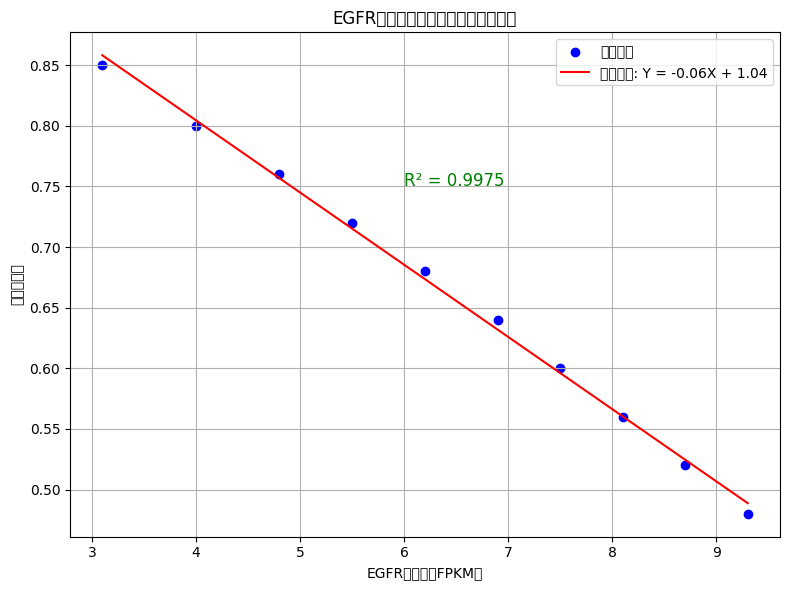

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 原始数据
X = [3.1,4.0,4.8,5.5,6.2,6.9,7.5,8.1,8.7,9.3]
Y = [0.85,0.80,0.76,0.72,0.68,0.64,0.60,0.56,0.52,0.48]

# 手算回归系数
mean_X = sum(X) / len(X)
mean_Y = sum(Y) / len(Y)
cov_XY = sum((X[i] - mean_X) * (Y[i] - mean_Y) for i in range(len(X)))
var_X = sum((x - mean_X)**2 for x in X)
a = cov_XY / var_X
b = mean_Y - a * mean_X

# 预测值
Y_pred = [a * x + b for x in X]

# 决定系数 R²
RSS = sum((Y[i] - Y_pred[i])**2 for i in range(len(Y)))
TSS = sum((y - mean_Y)**2 for y in Y)
R_squared = 1 - RSS / TSS

# 拟合线数据
X_fit = np.linspace(min(X), max(X), 100)
Y_fit = [a * x + b for x in X_fit]

# 绘图
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', label='原始数据')
plt.plot(X_fit, Y_fit, color='red', label=f'拟合直线: Y = {a:.2f}X + {b:.2f}')
plt.text(6.0, 0.75, f'R² = {R_squared:.4f}', fontsize=12, color='green')
plt.xlabel('EGFR表达量（FPKM）')
plt.ylabel('药物抑制率')
plt.title('EGFR表达量与药物抑制率的线性关系')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
